# Lab 5: Text Generation using RNN and LSTM
Character-level text generation trained on `sample.txt`.

In [1]:
# Task 1: Load Text
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import matplotlib.pyplot as plt

# Load text
with open("sample.txt", "r", encoding="utf-8") as f:
    text = f.read()

# Convert to lowercase to shrink vocabulary and help the model generalize
text = text.lower()

print(f"Text length: {len(text)} characters")
print(f"Preview (first 300 chars):\n{text[:300]}...")

Text length: 9350 characters
Preview (first 300 chars):
recurrent neural networks represent a paradigm shift in how machine learning handles time-series data because, unlike standard feedforward networks that treat each input as independent, rnns introduce a hidden state that acts as a form of internal memory to capture information from previous steps in...


In [2]:
# Task 2: Create Input Sequences — Character Vocabulary & Vectorization
# Build character vocabulary
chars = sorted(list(set(text)))
vocab_size = len(chars)

char_to_idx = {c: i for i, c in enumerate(chars)}
idx_to_char = {i: c for i, c in enumerate(chars)}

print(f"Vocabulary size: {vocab_size}")
print(f"Characters: {''.join(chars)}")

# Vectorize the text (convert every character to its integer index)
text_indices = np.array([char_to_idx[c] for c in text])
print(f"Vectorized text shape: {text_indices.shape}")
print(f"First 20 indices: {text_indices[:20]}")

Vocabulary size: 45
Characters: 
 "$()+,-.01\_abcdefghijklmnopqrstuvwxyz{}ü—’
Vectorized text shape: (9350,)
First 20 indices: [31 18 16 34 31 31 18 27 33  1 27 18 34 31 14 25  1 27 18 33]


In [3]:
# Task 3: Create Training Sequences
SEQ_LENGTH = 40   # shorter sequences = more training samples & easier to learn
STEP = 1          # sliding window step size

# Create input/output pairs using a sliding window
X_data = []
y_data = []

for i in range(0, len(text_indices) - SEQ_LENGTH, STEP):
    X_data.append(text_indices[i : i + SEQ_LENGTH])
    y_data.append(text_indices[i + SEQ_LENGTH])

X_data = np.array(X_data)
y_data = np.array(y_data)

print(f"Total sequences: {X_data.shape[0]}")

# One-hot encode the INPUTS (much richer than normalizing to 0-1)
X = to_categorical(X_data, num_classes=vocab_size)
# X shape: (samples, SEQ_LENGTH, vocab_size)

# One-hot encode the targets
y = to_categorical(y_data, num_classes=vocab_size)

print(f"X shape: {X.shape}  (samples, seq_len, vocab_size)")
print(f"y shape: {y.shape}")

# Train / validation split (90/10)
split = int(len(X) * 0.9)
X_train, X_val = X[:split], X[split:]
y_train, y_val = y[:split], y[split:]

print(f"Training sequences  : {X_train.shape[0]}")
print(f"Validation sequences: {X_val.shape[0]}")

Total sequences: 9310
X shape: (9310, 40, 45)  (samples, seq_len, vocab_size)
y shape: (9310, 45)
Training sequences  : 8379
Validation sequences: 931


In [4]:
# Task 4: Build RNN Model and LSTM Model
# --- SimpleRNN model (smaller to reduce overfitting on small dataset) ---
rnn_model = Sequential([
    SimpleRNN(64, input_shape=(SEQ_LENGTH, vocab_size)),
    Dropout(0.3),
    Dense(vocab_size, activation="softmax")
])
rnn_model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
rnn_model.summary()

# --- LSTM model (smaller + recurrent_dropout to reduce overfitting) ---
lstm_model = Sequential([
    LSTM(128, input_shape=(SEQ_LENGTH, vocab_size), recurrent_dropout=0.2),
    Dropout(0.3),
    Dense(vocab_size, activation="softmax")
])
lstm_model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
lstm_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 simple_rnn (SimpleRNN)      (None, 64)                7040      
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense (Dense)               (None, 45)                2925      
                                                                 
Total params: 9965 (38.93 KB)
Trainable params: 9965 (38.93 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 128)               89088     
                                                                 


Training SimpleRNN model
Epoch 1/50
131/131 [==============================] - 3s 10ms/step - loss: 3.1704 - accuracy: 0.1353 - val_loss: 2.9048 - val_accuracy: 0.1686 - lr: 0.0010
Epoch 2/50
131/131 [==============================] - 1s 8ms/step - loss: 2.8681 - accuracy: 0.1950 - val_loss: 2.7825 - val_accuracy: 0.2116 - lr: 0.0010
Epoch 3/50
131/131 [==============================] - 1s 8ms/step - loss: 2.7341 - accuracy: 0.2435 - val_loss: 2.6667 - val_accuracy: 0.2599 - lr: 0.0010
Epoch 4/50
131/131 [==============================] - 1s 8ms/step - loss: 2.6093 - accuracy: 0.2788 - val_loss: 2.5758 - val_accuracy: 0.2954 - lr: 0.0010
Epoch 5/50
131/131 [==============================] - 1s 8ms/step - loss: 2.5134 - accuracy: 0.3027 - val_loss: 2.5048 - val_accuracy: 0.2986 - lr: 0.0010
Epoch 6/50
131/131 [==============================] - 1s 8ms/step - loss: 2.4456 - accuracy: 0.3198 - val_loss: 2.4588 - val_accuracy: 0.3147 - lr: 0.0010
Epoch 7/50
131/131 [========================

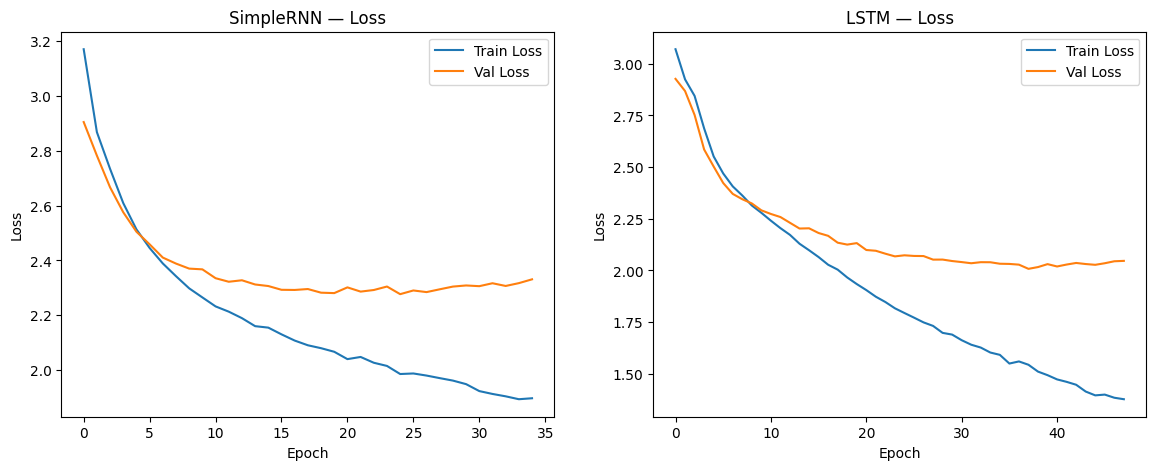

In [5]:
# Task 5: Train the Models
EPOCHS = 50
BATCH_SIZE = 64

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

print("=" * 60)
print("Training SimpleRNN model")
print("=" * 60)
rnn_history = rnn_model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=[reduce_lr, early_stop],
    verbose=1
)

print("\n" + "=" * 60)
print("Training LSTM model")
print("=" * 60)
lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=[reduce_lr, early_stop],
    verbose=1
)

# Plot training & validation loss
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(rnn_history.history["loss"], label="Train Loss")
axes[0].plot(rnn_history.history["val_loss"], label="Val Loss")
axes[0].set_title("SimpleRNN \u2014 Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(lstm_history.history["loss"], label="Train Loss")
axes[1].plot(lstm_history.history["val_loss"], label="Val Loss")
axes[1].set_title("LSTM \u2014 Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

In [6]:
# Task 6: Text Generation Function
def generate_text(model, seed_text, length=300, temperature=1.0):
    """
    Generate text character-by-character using a trained model.

    Args:
        model      : trained Keras model
        seed_text  : initial string (must be >= SEQ_LENGTH characters)
        length     : number of characters to generate
        temperature: controls randomness (lower = more deterministic)

    Returns:
        generated string (seed + new characters)
    """
    generated = list(seed_text)
    # Use the last SEQ_LENGTH characters as the working window
    window = [char_to_idx[c] for c in seed_text[-SEQ_LENGTH:]]

    for _ in range(length):
        # One-hot encode the current window
        x_pred = to_categorical(np.array(window[-SEQ_LENGTH:]), num_classes=vocab_size)
        x_pred = x_pred.reshape(1, SEQ_LENGTH, vocab_size)
        preds = model.predict(x_pred, verbose=0)[0]

        # Apply temperature scaling
        preds = np.log(preds + 1e-8) / temperature
        exp_preds = np.exp(preds)
        preds = exp_preds / np.sum(exp_preds)

        # Sample from the probability distribution
        next_idx = np.random.choice(len(preds), p=preds)
        next_char = idx_to_char[next_idx]

        generated.append(next_char)
        window.append(next_idx)

    return "".join(generated)

In [7]:
# Task 7: Generate New Text and Validate
# Use the first SEQ_LENGTH characters of the original text as seed
seed = text[:SEQ_LENGTH]
print(f"Seed text:\n\"{seed}\"\n")

temperatures = [0.5, 1.0, 1.2]

for temp in temperatures:
    print("=" * 70)
    print(f"  SimpleRNN \u2014 Temperature {temp}")
    print("=" * 70)
    rnn_output = generate_text(rnn_model, seed, length=300, temperature=temp)
    print(rnn_output)
    print()

    print("=" * 70)
    print(f"  LSTM \u2014 Temperature {temp}")
    print("=" * 70)
    lstm_output = generate_text(lstm_model, seed, length=300, temperature=temp)
    print(lstm_output)
    print()

# ----- Validation Summary -----
print("=" * 70)
print("VALIDATION SUMMARY")
print("=" * 70)
print(f"Training text length  : {len(text)} characters")
print(f"Vocabulary size       : {vocab_size}")
print(f"Sequence length       : {SEQ_LENGTH}")
print(f"Total training samples: {X_train.shape[0]}")
print(f"RNN final train loss  : {rnn_history.history['loss'][-1]:.4f}")
print(f"RNN final val loss    : {rnn_history.history['val_loss'][-1]:.4f}")
print(f"LSTM final train loss : {lstm_history.history['loss'][-1]:.4f}")
print(f"LSTM final val loss   : {lstm_history.history['val_loss'][-1]:.4f}")
print("\nConclusion: The generated text should resemble the style and")
print("vocabulary of the training data. Lower temperatures produce more")
print("conservative (repetitive) text, higher temperatures introduce more")
print("diversity and creativity.")

Seed text:
"recurrent neural networks represent a pa"

  SimpleRNN — Temperature 0.5
recurrent neural networks represent a patient the cempinting the and and the formethen the inatis the model tare the sing tha late sod ch conpus the aripnt the corus sing the ingate nunt ps ate nt the furd the forg the led chin ston lute th the veng the betws the puncen for les the vat ent the sempre bate the the preat on and arateing the

  LSTM — Temperature 0.5
recurrent neural networks represent a paint which archical formations of the model state tho the gate information formerand and allly memary the model to the forget gated in a sontels and and the newwork the new the medeving the network long the modes the forget and a stancell state sull the gate of the ceall sople to the state such a the

  SimpleRNN — Temperature 1.0
recurrent neural networks represent a panbinm the forg the memes entinyis the mrcaro tha 0hath to the morcinleare rofmomotily oftasilno toa peratient putig tisual d er stangori